In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import sympy as sp

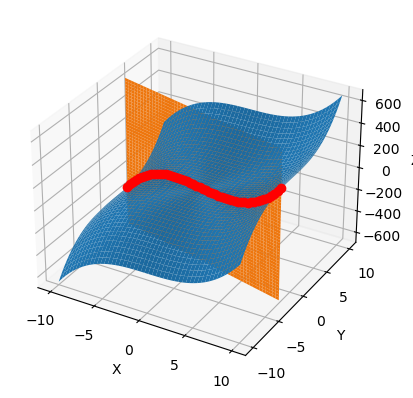

In [148]:
# upr 1 

# a)

x = np.linspace(-10, 10)
y = np.linspace(-10, 10)
X, Y = np.meshgrid(x, y)
Z = X**3 / 3 + Y**3 / 3

x1 = np.linspace(-10, 10)
z1 = np.linspace(min(Z.flatten()), max(Z.flatten()))
X1, Z1 = np.meshgrid(x1, z1)
Y1 = (1 - X1) / 4

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

yp = (1 - x) / 4
z = 1 / 3 * (1 - 4 * yp)**3 + 1 / 3 * yp**3

ax.plot3D(x, yp, z, 'r-o', linewidth=3, zorder=100)

ax.plot_surface(X, Y, Z)
ax.plot_surface(X1, Y1, Z1)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()

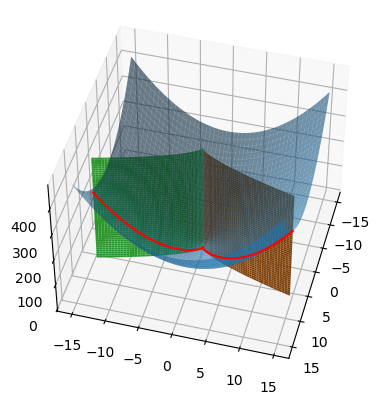

In [262]:
# upr 1 

# b)

x = np.linspace(-15, 15)
y = np.linspace(-15, 15)
X, Y = np.meshgrid(x, y)
Z = (X + 1)**2 + Y**2

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.view_init(azim=15, elev=45)
ax.plot_surface(X, Y, Z, alpha=0.6)

x = np.linspace(0, 6)
y1 = np.array([np.sqrt(i**3) for i in x])
Y, Z = np.meshgrid(y1, np.linspace(0, 400))
X = np.cbrt(Y**2)
ax.plot_surface(X, Y, Z)
ax.plot_surface(X, -Y, Z)

z = (x + 1)**2 + x**3
ax.plot(x, y1, z, zorder=1000, color='red')
ax.plot(x, -y1, z, zorder=1000, color='red')

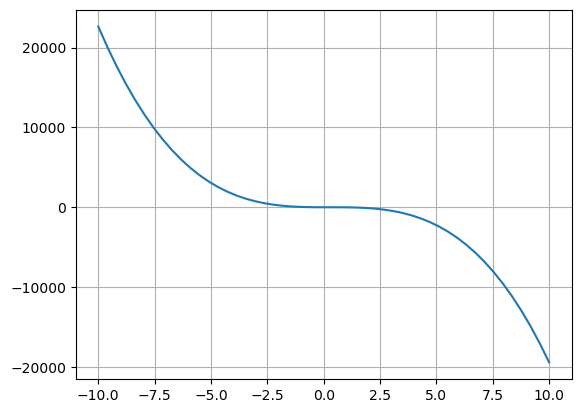

In [291]:
# upr 2

y = np.linspace(-10, 10)
z = 1 / 3 * (1 - 4 * y)**3 + 1 / 3 * y**3
plt.plot(y, z)
plt.grid()

In [353]:
y = sp.Symbol('y')
z = 1 / 3 * (1 - 4 * y)**3 + 1 / 3 * y**3
dzdy = sp.diff(z, y)
d2zdy2 = sp.diff(dydz, y)

In [354]:
s = sp.solve(dzdy, y)
print(s)
p0 = (s[0], 1 - 4 * s[0])[::-1]
p1 = (s[1], 1 - 4 * s[1])[::-1]
print(d2zdy2.subs(y, s[0]))
print(d2zdy2.subs(y, s[1]))
print(p0)
print(p1)

[0.222222222222222, 0.285714285714286]
4.00000000000000
-4.00000000000000
(0.111111111111111, 0.222222222222222)
(-0.142857142857143, 0.285714285714286)


Text(0.5, 0, 'Z')

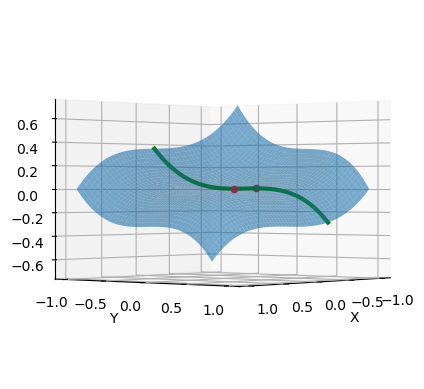

In [423]:
x = np.linspace(-1, 1)
y = np.linspace(-1, 1)
X, Y = np.meshgrid(x, y)
Z = X**3 / 3 + Y**3 / 3

x1 = np.linspace(-10, 10)
z1 = np.linspace(min(Z.flatten()), max(Z.flatten()))
X1, Z1 = np.meshgrid(x1, z1)
Y1 = (1 - X1) / 4

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

yp = (1 - x) / 4
z = 1 / 3 * (1 - 4 * yp)**3 + 1 / 3 * yp**3

ax.plot3D(x, yp, z, 'g-', linewidth=3, zorder=3)

ax.plot_surface(X, Y, Z, alpha=0.6)
# ax.plot_surface(X1, Y1, Z1)
z0 = 1 / 3 * (1 - 4 * p0[1])**3 + 1 / 3 * p0[1]**3
z1 = 1 / 3 * (1 - 4 * p1[1])**3 + 1 / 3 * p1[1]**3
ax.scatter(p0[0], p0[1], z0, color='r', s=20, zorder=2)
ax.scatter(p1[0], p1[1], z1, color='r', s=20, zorder=2)
ax.view_init(azim=40, elev=0)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

In [425]:
# upr 3
# a)

x = sp.Symbol('x')
y = sp.Symbol('y')
z = 1 / 3 * x**3 + 1 / 3 * y**3
phi = x + 4 * y - 1
print(sp.diff(z, x))
print(sp.diff(z, y))
print(sp.diff(phi, x))
print(sp.diff(phi, y))

1.0*x**2
1.0*y**2
1
4


In [426]:
# upr 3 
# b)

x = sp.Symbol('x')
y = sp.Symbol('y')
z = (x + 1)**2 + y**2
phi = y**2 - x**3
print(sp.diff(z, x))
print(sp.diff(z, y))
print(sp.diff(phi, x))
print(sp.diff(phi, y))

2*x + 2
2*y
-3*x**2
2*y


In [435]:
# upr 4

x = sp.Symbol('x')
y = sp.Symbol('y')
l = sp.Symbol('l')
L = 1 / 3 * x**3 + 1 / 3 * y**3 + l * (x + 4 * y - 1)
dldx = sp.diff(L, x)
dldy = sp.diff(L, y)
dldl = sp.diff(L, l)

In [438]:
stat = sp.solve((dldx, dldy, dldl), (x, y, l))
stat

[(-0.142857142857143, 0.285714285714286, -0.0204081632653061),
 (0.111111111111111, 0.222222222222222, -0.0123456790123457)]

In [450]:
def lagr_suff(L, phi, x, y, x0, y0, l0):
    dpdx = sp.diff(phi, x).subs({'x': x0, 'y': y0, 'l': l0})
    dpdy = sp.diff(phi, y).subs({'x': x0, 'y': y0, 'l': l0})
    d2ldx2 = sp.diff(sp.diff(L, x), x).subs({'x': x0, 'y': y0, 'l': l0})
    d2ldy2 = sp.diff(sp.diff(L, y), y).subs({'x': x0, 'y': y0, 'l': l0})
    d2ldxdy = sp.diff(sp.diff(L, x), y).subs({'x': x0, 'y': y0, 'l': l0})
    a = [[0, dpdx, dpdy], 
         [dpdx, d2ldx2, d2ldxdy], 
         [dpdy, d2ldxdy, d2ldy2]]
    # print(np.array(a, dtype=float))
    delta = -np.linalg.det(np.array(a, dtype=float))
    if (delta < 0):
        print(f'в точке ({x0}, {y0}) условный максимум')
    if (delta > 0):
        print(f'в точке ({x0}, {y0}) условный минимум')

In [451]:
lagr_suff(L, x + 4 * y - 1, x, y, *stat[0])

в точке (-0.142857142857143, 0.285714285714286) условный максимум


In [452]:
lagr_suff(L, x + 4 * y - 1, x, y, *stat[1])

в точке (0.111111111111111, 0.222222222222222) условный минимум


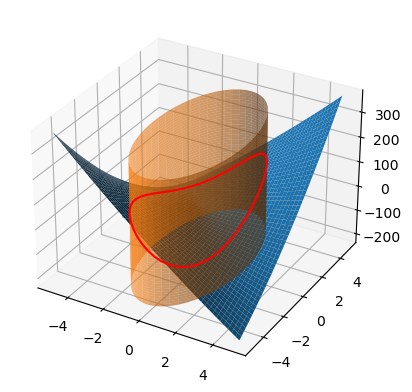

In [503]:
# upr 5

x = np.linspace(-5, 5)
y = np.linspace(-5, 5)
X, Y = np.meshgrid(x, y)
Z = X**2 + 12 * X * Y + 2 * Y**2

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.plot_surface(X, Y, Z)

# параметризуем фи(x, y) - это эллипс
t = np.linspace(0, 2 * np.pi)
t, z = np.meshgrid(t, np.linspace(-200, 300))
x = 5 / 2 * np.cos(t)
y = 5 * np.sin(t)
ax.plot_surface(x, y, z, alpha=0.6)

t = np.linspace(0, 2 * np.pi)
x = 5 / 2 * np.cos(t)
y = 5 * np.sin(t)
zp = []
for i, k in zip(x, y):
    zp.append(i**2 + 12 * i * k + k**2)

ax.plot(x, y, zp, color='r', zorder=10000)

# ax.view_init(azim=45, elev=30)

# ax.plot_surface(X, Y, Z1)

In [532]:
x = sp.Symbol('x')
y = sp.Symbol('y')
z = x**2 + 12 * x * y + y**2
phi = 4 * x**2 + y**2 - 25
print(sp.diff(z, x))
print(sp.diff(z, y))
print(sp.diff(phi, x))
print(sp.diff(phi, y))

L = z + l * phi
dldx = sp.diff(L, x)
dldy = sp.diff(L, y)
dldl = sp.diff(L, l)

2*x + 12*y
12*x + 2*y
8*x
2*y


In [541]:
stat = sp.solve((dldx, dldy, dldl), (x, y, l))
stat = [[k.evalf() for k in i] for i in stat]
stat

[[1.87419543953966, -3.30901281617870, 2.39834665561196],
 [-1.87419543953966, 3.30901281617870, 2.39834665561196],
 [1.65450640808935, 3.74839087907933, -3.64834665561196],
 [-1.65450640808935, -3.74839087907933, -3.64834665561196]]

In [543]:
for i in stat:
    lagr_suff(L, phi, x, y, *i)

в точке (1.87419543953966, -3.30901281617870) условный минимум
в точке (-1.87419543953966, 3.30901281617870) условный минимум
в точке (1.65450640808935, 3.74839087907933) условный максимум
в точке (-1.65450640808935, -3.74839087907933) условный максимум


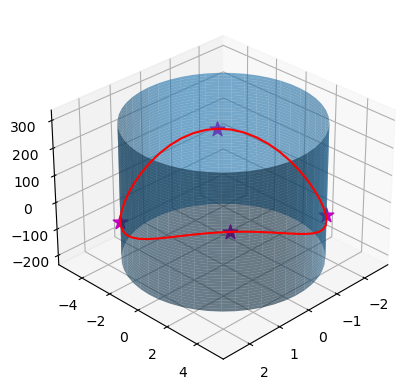

In [559]:
x = np.linspace(-5, 5)
y = np.linspace(-5, 5)
X, Y = np.meshgrid(x, y)
Z = X**2 + 12 * X * Y + 2 * Y**2

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

# ax.plot_surface(X, Y, Z, alpha=0.3)

# параметризуем фи(x, y) - это эллипс
t = np.linspace(0, 2 * np.pi)
t, z = np.meshgrid(t, np.linspace(-200, 300))
x = 5 / 2 * np.cos(t)
y = 5 * np.sin(t)
ax.plot_surface(x, y, z, alpha=0.6)

t = np.linspace(0, 2 * np.pi)
x = 5 / 2 * np.cos(t)
y = 5 * np.sin(t)
zp = []
for i, k in zip(x, y):
    zp.append(i**2 + 12 * i * k + k**2)

ax.plot(x, y, zp, color='r', zorder=10)

for i in stat:
    zp = i[0]**2 + 12 * i[0] * i[1] + i[1]**2
    ax.scatter(i[0], i[1], zp, color='m', marker='*', zorder=1000, s=120)
ax.view_init(azim=45, elev=30)